# Polynomial regression: fitting curves and testing generalization

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/evaluation/01-polynomial-model-validation.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

In this notebook, we predict nitrogen-oxides concentration (**NOX**) from ambient temperature (**AT**) with polynomial features. We will compare degree 1, degree 2, and degree 10 models using real gas-turbine measurements. The main question is not which curve fits the observed data most closely; it is which model is likely to work on operating hours it has not yet seen.

## 1. A small real-data subset

To make the behavior of flexible models easy to see, we deliberately work with a small subset of 60 real gas-turbine observations. A larger dataset can support high-degree fits more reliably and make overfitting less visually obvious. We set aside 35% of this subset as a **test set**.

The test observations are never used to fit the coefficients. We use them here to reveal what happens when a flexible model is applied to new observations. Later, we will distinguish a test set from a validation set and learn how to choose a model without repeatedly consulting the test data.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Use Seaborn's recognizable default dark-grid treatment and palette.
sns.set_theme(context="notebook", palette="deep")
deep_palette = sns.color_palette("deep")
training_color, test_color, fit_color = deep_palette[0], deep_palette[1], deep_palette[3]

# Use the local course CSV when available; download it in Colab otherwise.
DATA_URL = (
    "https://raw.githubusercontent.com/changyaochen/MECE4520/master/"
    "site/data/gas-turbine-course.csv"
)
data_path = Path("../data/gas-turbine-course.csv")
if not data_path.exists():
    data_path = Path("gas-turbine-course.csv")
    if not data_path.exists():
        urlretrieve(DATA_URL, data_path)

data = pd.read_csv(data_path)

# Fixing the random seed makes this small calibration exercise reproducible.
calibration_data = data[["AT", "NOX"]].dropna().sample(n=60, random_state=387)
train_data, test_data = train_test_split(
    calibration_data, test_size=0.35, random_state=479
)

print(f"Training observations: {len(train_data)}")
print(f"Test observations: {len(test_data)}")
train_data.head()

Training observations: 39
Test observations: 21


,AT,NOX
5169,26.412,61.849
24724,24.585,58.739
25761,27.772,47.277
9004,16.917,69.102
21515,16.364,76.489


## 2. Polynomial features are still features

A polynomial model of degree $d$ has the form

$$
\widehat{\mathrm{NOX}} = \beta_0 + \beta_1\mathrm{AT} + \beta_2\mathrm{AT}^2 + \cdots + \beta_d\mathrm{AT}^d.
$$

For degree 2, for example, the model receives two features: $\mathrm{AT}$ and $\mathrm{AT}^2$. The model is still linear in the unknown coefficients $\beta_0, \ldots, \beta_d$, so ordinary least squares can fit it.

We use a scikit-learn `Pipeline` to connect polynomial-feature construction to ordinary least squares, so the same expansion is used whenever the model predicts.

In [2]:
def polynomial_model(degree):
    """Create an ordinary least-squares model using AT through AT**degree."""
    return make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )

degrees = [1, 2, 10]
models = {}
metrics = []

for degree in degrees:
    model = polynomial_model(degree)
    model.fit(train_data[["AT"]], train_data["NOX"])
    models[degree] = model

    # Evaluate the same fitted model separately on seen and unseen observations.
    train_prediction = model.predict(train_data[["AT"]])
    test_prediction = model.predict(test_data[["AT"]])
    metrics.append(
        {
            "degree": degree,
            "training RMSE": mean_squared_error(train_data["NOX"], train_prediction) ** 0.5,
            "test RMSE": mean_squared_error(test_data["NOX"], test_prediction) ** 0.5,
            "training R²": r2_score(train_data["NOX"], train_prediction),
            "test R²": r2_score(test_data["NOX"], test_prediction),
        }
    )

metric_table = pd.DataFrame(metrics).set_index("degree")
metric_table.round(3)

,training RMSE,test RMSE,training R²,test R²
degree,,,,
1,9.916,8.530,0.302,0.045
2,9.808,8.059,0.317,0.147
10,7.918,12.518,0.555,-1.057


## 3. Compare training and test behavior

First, look only at the training observations: a flexible curve can trace their details closely. Then keep each fitted curve fixed and compare it with the held-out test observations. Separating the figures makes the contrast between fitting and generalizing easier to see.

The legend in each figure reports only the corresponding error metrics. RMSE retains the physical units of NOX, while $R^2$ reports the fraction of variation explained relative to predicting the relevant sample mean.

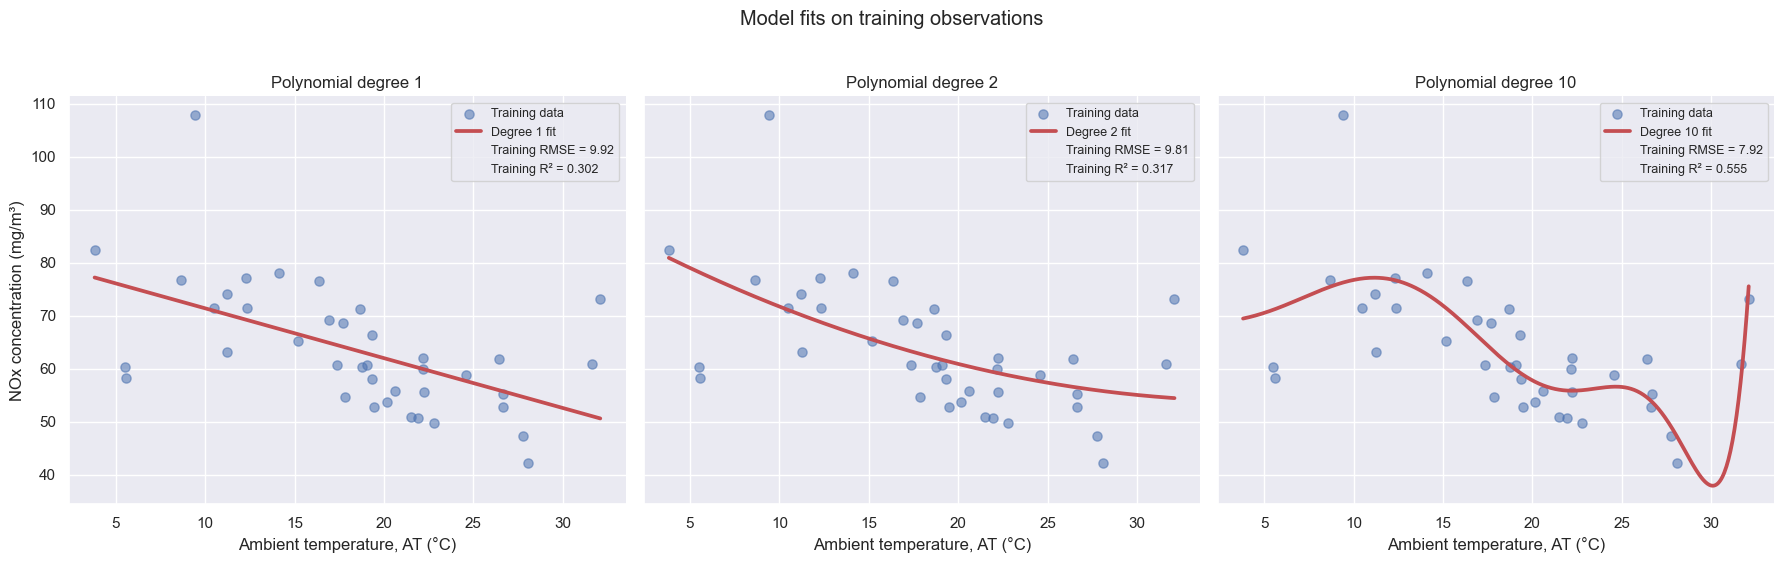

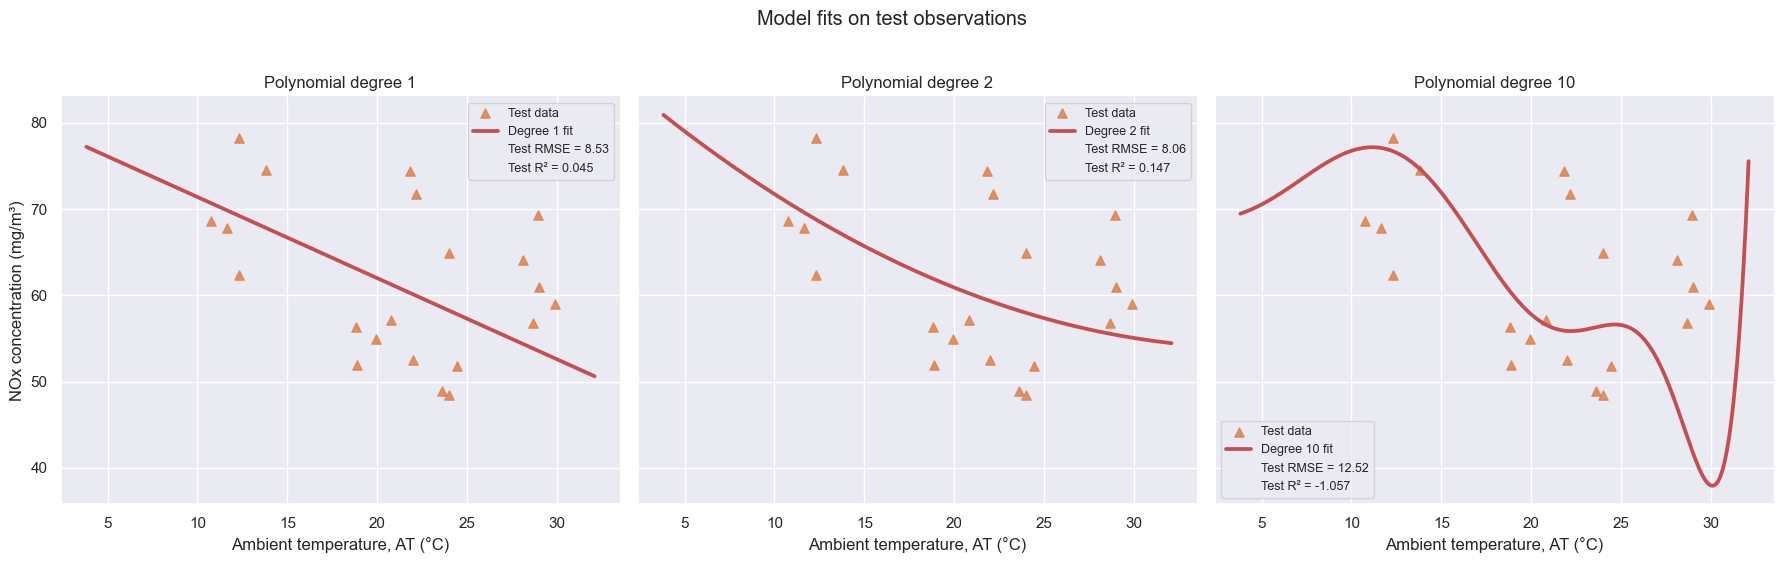

In [3]:
# Use a common grid and common axes so the three curves are directly comparable.
at_grid = np.linspace(calibration_data["AT"].min(), calibration_data["AT"].max(), 500)
x_grid = pd.DataFrame({"AT": at_grid})

def plot_models_for_split(display_data, split_name, color, marker, alpha, metric_prefix):
    """Show the three already-fitted curves against one data split."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)

    for axis, degree in zip(axes, degrees):
        model = models[degree]
        row = metric_table.loc[degree]

        axis.scatter(
            display_data["AT"], display_data["NOX"],
            color=color, marker=marker, alpha=alpha, s=44, label=f"{split_name} data"
        )
        axis.plot(
            at_grid, model.predict(x_grid), color=fit_color, linewidth=2.7,
            label=f"Degree {degree} fit"
        )

        # Empty handles place the metrics for this split directly in the legend.
        axis.plot([], [], " ", label=f"{split_name} RMSE = {row[f'{metric_prefix} RMSE']:.2f}")
        axis.plot([], [], " ", label=f"{split_name} R² = {row[f'{metric_prefix} R²']:.3f}")

        axis.set_title(f"Polynomial degree {degree}")
        axis.set_xlabel("Ambient temperature, AT (°C)")
        axis.legend(loc="best", fontsize=9, frameon=True)
        sns.despine(ax=axis)

    axes[0].set_ylabel("NOx concentration (mg/m³)")
    fig.suptitle(f"Model fits on {split_name.lower()} observations", y=1.02)
    fig.tight_layout()
    plt.show()

# The models were fitted only on this first group of observations.
plot_models_for_split(train_data, "Training", training_color, "o", 0.55, "training")

# These held-out observations were never used while fitting any curve.
plot_models_for_split(test_data, "Test", test_color, "^", 0.88, "test")

## 4. How error changes with polynomial degree

The three panels compare a few specific models. We can also fit a sequence of increasingly flexible polynomial models and summarize the result with RMSE. Degree 0 is the baseline model that predicts the training-set mean NOX for every observation; degree 1 adds AT; each later degree adds one additional power of AT.

The training curve should fall as the model gains flexibility. The test curve initially falls when a useful feature is added, then rises once added flexibility starts fitting details that do not repeat in held-out observations.

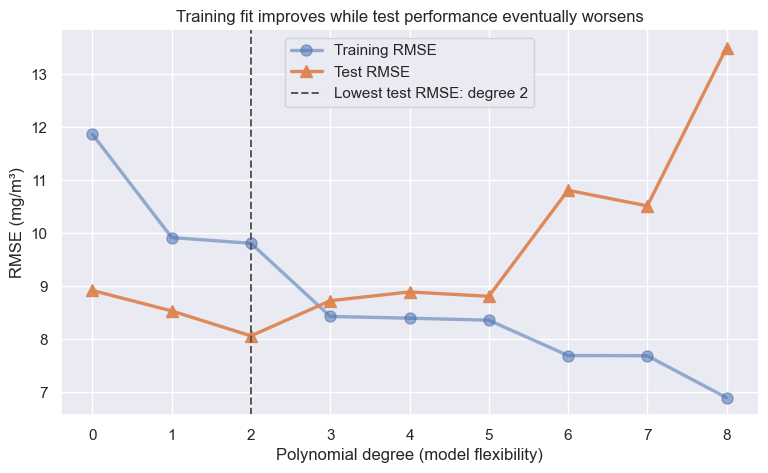

,training RMSE,test RMSE
degree,,
0,11.867,8.917
1,9.916,8.530
2,9.808,8.059
3,8.425,8.723
4,8.393,8.889
5,8.355,8.806
6,7.687,10.810
7,7.683,10.514
8,6.891,13.504


In [4]:
evaluation_degrees = list(range(9))
error_by_degree = []

for degree in evaluation_degrees:
    if degree == 0:
        # The degree-0 baseline predicts the training-set mean for every row.
        train_prediction = np.full(len(train_data), train_data["NOX"].mean())
        test_prediction = np.full(len(test_data), train_data["NOX"].mean())
    else:
        model = polynomial_model(degree)
        model.fit(train_data[["AT"]], train_data["NOX"])
        train_prediction = model.predict(train_data[["AT"]])
        test_prediction = model.predict(test_data[["AT"]])

    error_by_degree.append(
        {
            "degree": degree,
            "training RMSE": mean_squared_error(train_data["NOX"], train_prediction) ** 0.5,
            "test RMSE": mean_squared_error(test_data["NOX"], test_prediction) ** 0.5,
        }
    )

error_by_degree = pd.DataFrame(error_by_degree).set_index("degree")
best_degree = error_by_degree["test RMSE"].idxmin()

fig, axis = plt.subplots(figsize=(9, 5))
axis.plot(
    error_by_degree.index, error_by_degree["training RMSE"],
    marker="o", markersize=8, linewidth=2.4, color=training_color, alpha=0.55,
    label="Training RMSE"
)
axis.plot(
    error_by_degree.index, error_by_degree["test RMSE"],
    marker="^", markersize=8, linewidth=2.4, color=test_color, alpha=0.95,
    label="Test RMSE"
)
axis.axvline(
    best_degree, color="#555555", linestyle="--", linewidth=1.4,
    label=f"Lowest test RMSE: degree {best_degree}"
)
axis.set(
    title="Training fit improves while test performance eventually worsens",
    xlabel="Polynomial degree (model flexibility)",
    ylabel="RMSE (mg/m³)",
    xticks=evaluation_degrees,
)
axis.legend()
sns.despine(ax=axis)
plt.show()

error_by_degree.round(3)

## 5. What does the comparison show?

The degree-10 model has enough flexibility to chase details of this limited training sample, especially near the ends of the observed temperature range. Its training RMSE can therefore look attractive even when its test RMSE is worse. This is **overfitting**: the fitted curve has learned sample-specific variation that does not repeat in new observations.

A held-out test set can reveal this problem, but it should not be consulted repeatedly while trying many degrees, feature sets, or tuning parameters. In the next step of the course, we will use validation data and cross-validation to make those choices while preserving a final test set for honest evaluation.

## Takeaways

- Polynomial terms such as $\mathrm{AT}^2$ and $\mathrm{AT}^{10}$ are additional features; the model remains linear in its coefficients.
- Training error alone rewards flexibility and cannot identify overfitting.
- Test RMSE estimates prediction error on observations not used to fit the coefficients.
- The apparent best degree depends on the particular split, motivating validation and cross-validation.

[Return to Evaluation](index.qmd)